In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

traffic = pd.read_csv(
    "../data/predictions/traffic_forecast_predictions.csv"
)

worklist = pd.read_csv(
    "../data/predictions/ranked_maintenance_worklist.csv"
)

traffic["date"] = pd.to_datetime(
    traffic["date"]
)

print("Traffic shape:", traffic.shape)
print("Worklist shape:", worklist.shape)

display(traffic.head())
display(worklist.head())

Traffic shape: (2430, 10)
Worklist shape: (6, 17)


,date,section_id,total_trains,passenger_trains,freight_trains,lag_1,lag_7,rolling_7,predicted_total_trains,forecast_error
0,2026-01-01,AGC-GWL-01,258,153,105,253.0,249.0,240.285714,253.589540,-4.410460
1,2026-01-01,BINA-BPL-01,197,121,76,192.0,184.0,181.142857,191.638284,-5.361716
2,2026-01-01,BPL-RTM-01,185,112,73,178.0,181.0,171.142857,182.724145,-2.275855
3,2026-01-01,GWL-JHS-01,240,145,95,233.0,238.0,226.428571,238.287108,-1.712892
4,2026-01-01,JHS-BINA-01,199,121,78,185.0,186.0,178.285714,188.939437,-10.060563


,priority_rank,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,overdue_days,estimated_duration,required_manpower,status,failure_probability,urgency_score,priority_score,priority_category
0,1,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,1,90,8,PENDING,0.0,0.718333,0.418833,MEDIUM
1,2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,0,45,3,PENDING,0.0,0.635000,0.370500,MEDIUM
2,3,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,0,60,5,PENDING,0.0,0.595000,0.358500,MEDIUM
3,4,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,0,60,5,PENDING,0.0,0.440000,0.292000,MEDIUM
4,5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,OHE_CHECK,3,8,0,45,4,PENDING,0.0,0.400000,0.280000,MEDIUM


In [2]:
print("Traffic columns:")
print(traffic.columns.tolist())

print("\nMaintenance columns:")
print(worklist.columns.tolist())

Traffic columns:
['date', 'section_id', 'total_trains', 'passenger_trains', 'freight_trains', 'lag_1', 'lag_7', 'rolling_7', 'predicted_total_trains', 'forecast_error']

Maintenance columns:
['priority_rank', 'task_id', 'asset_id', 'section_id', 'department', 'maintenance_type', 'defect_type', 'severity', 'criticality', 'overdue_days', 'estimated_duration', 'required_manpower', 'status', 'failure_probability', 'urgency_score', 'priority_score', 'priority_category']


In [3]:
traffic_section = (
    traffic
    .groupby("section_id")
    .agg(
        avg_predicted_trains=(
            "predicted_total_trains",
            "mean"
        ),
        max_predicted_trains=(
            "predicted_total_trains",
            "max"
        ),
        avg_passenger_trains=(
            "passenger_trains",
            "mean"
        ),
        avg_freight_trains=(
            "freight_trains",
            "mean"
        )
    )
    .reset_index()
)

display(traffic_section)

,section_id,avg_predicted_trains,max_predicted_trains,avg_passenger_trains,avg_freight_trains
0,AGC-GWL-01,243.576523,263.676719,142.366255,101.674897
1,BINA-BPL-01,183.801826,205.219391,107.275720,76.736626
2,BPL-RTM-01,174.095320,189.626549,101.345679,72.572016
3,GWL-JHS-01,230.368920,250.817393,134.502058,95.884774
4,JHS-BINA-01,183.568691,205.165773,107.152263,76.609053
5,MTJ-AGC-01,266.781484,288.945939,155.674897,111.234568
6,NDL-MTJ-01,206.941964,225.812249,120.506173,86.185185
7,RTM-VAD-01,258.377722,280.842540,150.621399,107.921811
8,SRT-MUM-01,242.128109,263.792584,141.189300,100.868313
9,VAD-SRT-01,230.230540,249.149985,134.139918,95.983539


In [4]:
impact_data = worklist.merge(
    traffic_section,
    on="section_id",
    how="left"
)

print("Impact dataset shape:", impact_data.shape)

display(
    impact_data.head(20)
)

Impact dataset shape: (6, 21)


,priority_rank,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,overdue_days,...,required_manpower,status,failure_probability,urgency_score,priority_score,priority_category,avg_predicted_trains,max_predicted_trains,avg_passenger_trains,avg_freight_trains
0,1,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,1,...,8,PENDING,0.0,0.718333,0.418833,MEDIUM,206.941964,225.812249,120.506173,86.185185
1,2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,0,...,3,PENDING,0.0,0.635000,0.370500,MEDIUM,266.781484,288.945939,155.674897,111.234568
2,3,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,0,...,5,PENDING,0.0,0.595000,0.358500,MEDIUM,230.368920,250.817393,134.502058,95.884774
3,4,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,0,...,5,PENDING,0.0,0.440000,0.292000,MEDIUM,NaN,NaN,NaN,NaN
4,5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,OHE_CHECK,3,8,0,...,4,PENDING,0.0,0.400000,0.280000,MEDIUM,183.568691,205.165773,107.152263,76.609053
5,6,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,SIGNAL_CHECK,3,7,0,...,2,PENDING,0.0,0.365000,0.249500,LOW,243.576523,263.676719,142.366255,101.674897


In [5]:
traffic_columns = [
    "avg_predicted_trains",
    "max_predicted_trains",
    "avg_passenger_trains",
    "avg_freight_trains"
]

for column in traffic_columns:
    impact_data[column] = pd.to_numeric(
        impact_data[column],
        errors="coerce"
    ).fillna(0)

print("Traffic features cleaned.")

Traffic features cleaned.


In [6]:
max_traffic = impact_data[
    "max_predicted_trains"
].max()

if max_traffic > 0:
    impact_data["traffic_intensity"] = (
        impact_data["avg_predicted_trains"]
        / max_traffic
    ).clip(0, 1)
else:
    impact_data["traffic_intensity"] = 0

display(
    impact_data[
        [
            "section_id",
            "avg_predicted_trains",
            "max_predicted_trains",
            "traffic_intensity"
        ]
    ].head(20)
)

,section_id,avg_predicted_trains,max_predicted_trains,traffic_intensity
0,NDL-MTJ-01,206.941964,225.812249,0.716196
1,MTJ-AGC-01,266.781484,288.945939,0.923292
2,GWL-JHS-01,230.368920,250.817393,0.797273
3,NDL-MTJ-02,0.000000,0.000000,0.000000
4,JHS-BINA-01,183.568691,205.165773,0.635305
5,AGC-GWL-01,243.576523,263.676719,0.842983


In [7]:
impact_data["estimated_duration"] = pd.to_numeric(
    impact_data["estimated_duration"],
    errors="coerce"
).fillna(0)

impact_data["affected_trains_estimate"] = (
    impact_data["avg_predicted_trains"]
    * impact_data["estimated_duration"]
    / (24 * 60)
)

In [8]:
np.random.seed(42)

passenger_factor = (
    impact_data["avg_passenger_trains"]
    / impact_data["avg_predicted_trains"].replace(0, np.nan)
).fillna(0)

freight_factor = (
    impact_data["avg_freight_trains"]
    / impact_data["avg_predicted_trains"].replace(0, np.nan)
).fillna(0)

impact_data["synthetic_delay_minutes"] = (
    5
    + 0.8 * impact_data["estimated_duration"]
    * impact_data["traffic_intensity"]
    + 15 * impact_data["affected_trains_estimate"]
    + 5 * passenger_factor
    + 3 * freight_factor
    + np.random.normal(
        0,
        2,
        len(impact_data)
    )
)

impact_data["synthetic_delay_minutes"] = (
    impact_data["synthetic_delay_minutes"]
    .clip(lower=0)
    .round(2)
)

display(
    impact_data[
        [
            "task_id",
            "section_id",
            "estimated_duration",
            "traffic_intensity",
            "affected_trains_estimate",
            "synthetic_delay_minutes"
        ]
    ].head(20)
)

,task_id,section_id,estimated_duration,traffic_intensity,affected_trains_estimate,synthetic_delay_minutes
0,TMS001,NDL-MTJ-01,90,0.716196,12.933873,255.73
1,SMMS001,MTJ-AGC-01,45,0.923292,8.336921,167.18
2,TDMS001,GWL-JHS-01,60,0.797273,9.598705,192.71
3,TMS002,NDL-MTJ-02,60,0.000000,0.000000,8.05
4,TDMS002,JHS-BINA-01,45,0.635305,5.736522,117.62
5,SMMS002,AGC-GWL-01,30,0.842983,5.074511,105.06


In [9]:
duration_risk = (
    impact_data["estimated_duration"] / 180
).clip(0, 1)

traffic_risk = (
    impact_data["traffic_intensity"]
).clip(0, 1)

affected_train_risk = (
    impact_data["affected_trains_estimate"] / 5
).clip(0, 1)

impact_data["operational_impact_score"] = (
    0.40 * duration_risk
    + 0.35 * traffic_risk
    + 0.25 * affected_train_risk
)

impact_data["operational_impact_category"] = pd.cut(
    impact_data["operational_impact_score"],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        np.inf
    ],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "CRITICAL"
    ]
)

display(
    impact_data[
        [
            "task_id",
            "section_id",
            "operational_impact_score",
            "operational_impact_category"
        ]
    ].head(20)
)

,task_id,section_id,operational_impact_score,operational_impact_category
0,TMS001,NDL-MTJ-01,0.700669,HIGH
1,SMMS001,MTJ-AGC-01,0.673152,HIGH
2,TDMS001,GWL-JHS-01,0.662379,HIGH
3,TMS002,NDL-MTJ-02,0.133333,LOW
4,TDMS002,JHS-BINA-01,0.572357,HIGH
5,SMMS002,AGC-GWL-01,0.611711,HIGH


In [11]:
highest_impact = (
    impact_data[
        [
            "task_id",
            "asset_id",
            "section_id",
            "department",
            "maintenance_type",
            "estimated_duration",
            "avg_predicted_trains",
            "traffic_intensity",
            "affected_trains_estimate",
            "synthetic_delay_minutes",
            "operational_impact_score",
            "operational_impact_category"
        ]
    ]
    .sort_values(
        "operational_impact_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(highest_impact.head(20))

,task_id,asset_id,section_id,department,maintenance_type,estimated_duration,avg_predicted_trains,traffic_intensity,affected_trains_estimate,synthetic_delay_minutes,operational_impact_score,operational_impact_category
0,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,90,206.941964,0.716196,12.933873,255.73,0.700669,HIGH
1,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,45,266.781484,0.923292,8.336921,167.18,0.673152,HIGH
2,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,60,230.368920,0.797273,9.598705,192.71,0.662379,HIGH
3,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,30,243.576523,0.842983,5.074511,105.06,0.611711,HIGH
4,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,45,183.568691,0.635305,5.736522,117.62,0.572357,HIGH
5,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,60,0.000000,0.000000,0.000000,8.05,0.133333,LOW


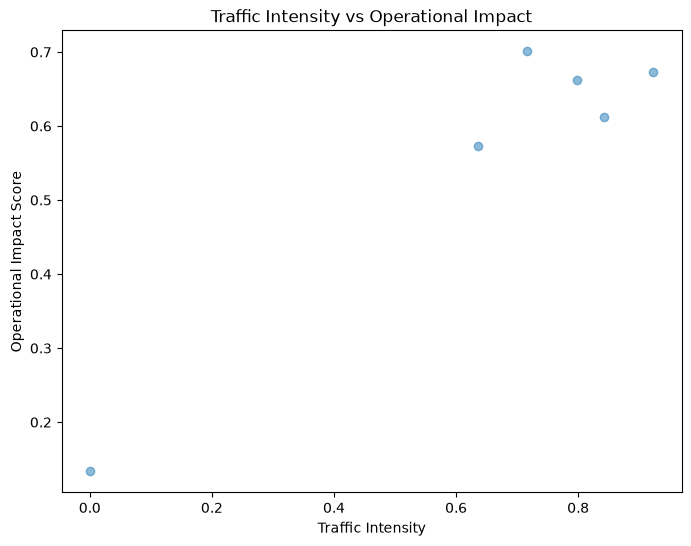

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    impact_data["traffic_intensity"],
    impact_data["operational_impact_score"],
    alpha=0.5
)

plt.xlabel("Traffic Intensity")
plt.ylabel("Operational Impact Score")
plt.title(
    "Traffic Intensity vs Operational Impact"
)

plt.show()

In [13]:
impact_features = [
    "estimated_duration",
    "severity",
    "criticality",
    "overdue_days",
    "required_manpower",
    "avg_predicted_trains",
    "avg_passenger_trains",
    "avg_freight_trains",
    "traffic_intensity",
    "affected_trains_estimate"
]

impact_target = "synthetic_delay_minutes"

In [15]:
X_impact = impact_data[
    impact_features
]

y_impact = impact_data[
    impact_target
]

print("Features:", impact_features)
print("Target:", impact_target)
print("Dataset shape:", X_impact.shape)

Features: ['estimated_duration', 'severity', 'criticality', 'overdue_days', 'required_manpower', 'avg_predicted_trains', 'avg_passenger_trains', 'avg_freight_trains', 'traffic_intensity', 'affected_trains_estimate']
Target: synthetic_delay_minutes
Dataset shape: (6, 10)


In [17]:
# Load original maintenance data to recover task creation dates
maintenance_raw = pd.read_csv(
    "../data/raw/maintenance.csv"
)

maintenance_raw["created_date"] = pd.to_datetime(
    maintenance_raw["created_date"],
    errors="coerce"
)

# Keep only the columns we need
task_dates = maintenance_raw[
    ["task_id", "created_date"]
].drop_duplicates(
    subset=["task_id"]
)

# Add created_date to the operational impact dataset
impact_data = impact_data.merge(
    task_dates,
    on="task_id",
    how="left"
)

print("created_date successfully added.")

print(
    "Missing created dates:",
    impact_data["created_date"].isna().sum()
)

display(
    impact_data[
        [
            "task_id",
            "section_id",
            "created_date"
        ]
    ].head(20)
)

created_date successfully added.
Missing created dates: 0


,task_id,section_id,created_date
0,TMS001,NDL-MTJ-01,2026-08-20
1,SMMS001,MTJ-AGC-01,2026-08-22
2,TDMS001,GWL-JHS-01,2026-08-18
3,TMS002,NDL-MTJ-02,2026-08-25
4,TDMS002,JHS-BINA-01,2026-08-29
5,SMMS002,AGC-GWL-01,2026-08-28


In [18]:
impact_data = impact_data.sort_values(
    "created_date"
).reset_index(drop=True)

split_index = int(
    len(impact_data) * 0.80
)

impact_train = impact_data.iloc[
    :split_index
].copy()

impact_test = impact_data.iloc[
    split_index:
].copy()

print("Training rows:", len(impact_train))
print("Testing rows:", len(impact_test))

print(
    "Training date range:",
    impact_train["created_date"].min(),
    "to",
    impact_train["created_date"].max()
)

print(
    "Testing date range:",
    impact_test["created_date"].min(),
    "to",
    impact_test["created_date"].max()
)

Training rows: 4
Testing rows: 2
Training date range: 2026-08-18 00:00:00 to 2026-08-25 00:00:00
Testing date range: 2026-08-28 00:00:00 to 2026-08-29 00:00:00


In [19]:
impact_data = impact_data.sort_values(
    "created_date"
).reset_index(drop=True)

split_index = int(
    len(impact_data) * 0.80
)

impact_train = impact_data.iloc[
    :split_index
].copy()

impact_test = impact_data.iloc[
    split_index:
].copy()

print("Training rows:", len(impact_train))
print("Testing rows:", len(impact_test))

print(
    "Training date range:",
    impact_train["created_date"].min(),
    "to",
    impact_train["created_date"].max()
)

print(
    "Testing date range:",
    impact_test["created_date"].min(),
    "to",
    impact_test["created_date"].max()
)

Training rows: 4
Testing rows: 2
Training date range: 2026-08-18 00:00:00 to 2026-08-25 00:00:00
Testing date range: 2026-08-28 00:00:00 to 2026-08-29 00:00:00


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Recreate training and testing data
X_impact_train = impact_train[
    impact_features
]

y_impact_train = impact_train[
    impact_target
]

X_impact_test = impact_test[
    impact_features
]

y_impact_test = impact_test[
    impact_target
]

# Recreate the operational impact model
impact_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train the model
impact_model.fit(
    X_impact_train,
    y_impact_train
)

# Generate predictions
impact_predictions = impact_model.predict(
    X_impact_test
)

# Evaluate
impact_mae = mean_absolute_error(
    y_impact_test,
    impact_predictions
)

impact_rmse = np.sqrt(
    mean_squared_error(
        y_impact_test,
        impact_predictions
    )
)

impact_r2 = r2_score(
    y_impact_test,
    impact_predictions
)

print("Operational Impact Model")
print("------------------------")
print("MAE :", round(impact_mae, 2), "minutes")
print("RMSE:", round(impact_rmse, 2), "minutes")
print("R²  :", round(impact_r2, 3))

Operational Impact Model
------------------------
MAE : 48.95 minutes
RMSE: 49.35 minutes
R²  : -60.752


In [24]:
impact_importance = pd.DataFrame({
    "feature": impact_features,
    "importance": impact_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(impact_importance)

,feature,importance
0,estimated_duration,0.0
1,severity,0.0
2,criticality,0.0
3,overdue_days,0.0
4,required_manpower,0.0
5,avg_predicted_trains,0.0
6,avg_passenger_trains,0.0
7,avg_freight_trains,0.0
8,traffic_intensity,0.0
9,affected_trains_estimate,0.0


In [25]:
impact_results = impact_test[
    [
        "task_id",
        "asset_id",
        "section_id",
        "department",
        "maintenance_type",
        "estimated_duration",
        "avg_predicted_trains",
        "avg_passenger_trains",
        "avg_freight_trains",
        "traffic_intensity",
        "affected_trains_estimate",
        "synthetic_delay_minutes",
        "operational_impact_score",
        "operational_impact_category"
    ]
].copy()

impact_results["predicted_delay_minutes"] = (
    impact_predictions
)

impact_results["delay_prediction_error"] = (
    impact_results["predicted_delay_minutes"]
    - impact_results["synthetic_delay_minutes"]
)

display(impact_results)

,task_id,asset_id,section_id,department,maintenance_type,estimated_duration,avg_predicted_trains,avg_passenger_trains,avg_freight_trains,traffic_intensity,affected_trains_estimate,synthetic_delay_minutes,operational_impact_score,operational_impact_category,predicted_delay_minutes,delay_prediction_error
4,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,30,243.576523,142.366255,101.674897,0.842983,5.074511,105.06,0.611711,HIGH,160.288458,55.228458
5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,45,183.568691,107.152263,76.609053,0.635305,5.736522,117.62,0.572357,HIGH,160.288458,42.668458


In [26]:
impact_results.to_csv(
    "../data/predictions/operational_impact_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../data/predictions/operational_impact_predictions.csv"
)

Saved: ../data/predictions/operational_impact_predictions.csv
